In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import datetime as datetime
import pandas as pd

In [66]:
# Clean Data

PAIRS = [
    ("V", "MA", "Data/V_daily.csv", "Data/MA_daily.csv"),
    ("PEP", "KO", "Data/PEP_daily.csv", "Data/KO_daily.csv"),
    ("XOM", "CVX", "Data/XOM_daily.csv", "Data/CVX_daily.csv"),
    ("JPM", "BAC", "Data/JPM_daily.csv", "Data/BAC_daily.csv"),
    ("GOOG", "GOOGL", "Data/GOOG_daily.csv", "Data/GOOGL_daily.csv"),
    ("SPY", "IVV", "Data/SPY_daily.csv", "Data/IVV_daily.csv"),
    ("GLD", "IAU", "Data/GLD_daily.csv", "Data/IAU_daily.csv"),
    ("AGG", "BND", "Data/AGG_daily.csv", "Data/BND_daily.csv"),
    ("VTI", "SCHB", "Data/VTI_daily.csv", "Data/SCHB_daily.csv"),
]


def load_yfinance_csv(path, ticker):
    asset = pd.read_csv(path)
    asset = asset.iloc[2:].copy()
    asset = asset.rename(columns={"Price": "Date", "Adj Close": ticker})
    asset = asset[["Date", ticker]].copy()
    asset["Date"] = pd.to_datetime(asset["Date"], errors="coerce")
    asset[ticker] = pd.to_numeric(asset[ticker], errors="coerce")
    asset = asset.dropna(subset=["Date", ticker])
    return asset


pair_data = {}

for y_ticker, x_ticker, y_path, x_path in PAIRS:
    y_asset = load_yfinance_csv(y_path, y_ticker)
    x_asset = load_yfinance_csv(x_path, x_ticker)

    pair_df = y_asset.merge(x_asset, on="Date", how="inner")
    pair_df = pair_df.sort_values("Date").reset_index(drop=True)
    pair_df = pair_df[(pair_df[y_ticker] > 0) & (pair_df[x_ticker] > 0)].copy()

    pair_df[f"log_{y_ticker}"] = np.log(pair_df[y_ticker])
    pair_df[f"log_{x_ticker}"] = np.log(pair_df[x_ticker])
    pair_df = pair_df.dropna().reset_index(drop=True)

    pair_data[(y_ticker, x_ticker)] = pair_df

In [67]:
# Defining periods for training, validation and testing

TRAIN_START = "2015-01-01"
TRAIN_END = "2018-12-31"

VALID_START = "2019-01-01"
VALID_END = "2021-12-31"

TEST_START = "2022-01-01"

train_pair_data = {
    pair: pair_df[(pair_df["Date"] >= TRAIN_START) & (pair_df["Date"] <= TRAIN_END)].copy()
    for pair, pair_df in pair_data.items()
}
valid_pair_data = {
    pair: pair_df[(pair_df["Date"] >= VALID_START) & (pair_df["Date"] <= VALID_END)].copy()
    for pair, pair_df in pair_data.items()
}
test_pair_data = {
    pair: pair_df[pair_df["Date"] >= TEST_START].copy()
    for pair, pair_df in pair_data.items()
}

In [68]:
# Check for cointegration

def cointegration_gate(y, x, pvalue_threshold=0.1):
    x_const = sm.add_constant(x)
    model = sm.OLS(y, x_const).fit()

    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]

    residual = y - alpha - beta * x

    adf_result = adfuller(residual.dropna())
    adf_stat = adf_result[0]
    adf_pvalue = adf_result[1]

    passed = adf_pvalue < pvalue_threshold

    return {
        "passed": passed,
        "alpha": alpha,
        "beta": beta,
        "residual": residual,
        "adf_stat": adf_stat,
        "adf_pvalue": adf_pvalue,
    }

cointegration_results = {}

for y_ticker, x_ticker, *_ in PAIRS:
    train_df = train_pair_data[(y_ticker, x_ticker)]
    pair_name = f"{y_ticker}/{x_ticker}"

    gate1 = cointegration_gate(
        y=train_df[f"log_{y_ticker}"],
        x=train_df[f"log_{x_ticker}"],
        pvalue_threshold=0.1
    )

    cointegration_results[pair_name] = gate1
    status = "Pass" if gate1["passed"] else "Reject"
    print(f"{pair_name}: {status}; adf_pvalue={gate1['adf_pvalue']:.6f}")

V/MA: Pass; adf_pvalue=0.095355
PEP/KO: Reject; adf_pvalue=0.289744
XOM/CVX: Pass; adf_pvalue=0.067826
JPM/BAC: Pass; adf_pvalue=0.033963
GOOG/GOOGL: Pass; adf_pvalue=0.046699
SPY/IVV: Reject; adf_pvalue=0.337883
GLD/IAU: Reject; adf_pvalue=0.491664
AGG/BND: Reject; adf_pvalue=0.419535
VTI/SCHB: Reject; adf_pvalue=0.302285


In [69]:
# Check for quality of mean reversion

def mean_reversion_gate(alpha, min_half_life = 2, max_half_life= 63):
    alpha = alpha.dropna()

    x = alpha.iloc[:-1]
    y = alpha.iloc[1:]

    phi, intercept = np.polyfit(x, y, 1)

    if phi <= 0 or phi >= 1:
        return {
            "passed": False,
            "phi": phi,
            "half_life": np.nan,
            "reason": "Not mean-reverting"
        }

    theta = -np.log(phi)
    half_life = np.log(2) / theta

    passed = min_half_life <= half_life <= max_half_life

    return {
        "passed": passed,
        "phi": phi,
        "theta": theta,
        "half_life": half_life,
        "reason": "Passed" if passed else "Bad half-life"
    }

mean_reversion_results = {}

for y_ticker, x_ticker, *_ in PAIRS:
    train_df = train_pair_data[(y_ticker, x_ticker)]
    pair_name = f"{y_ticker}/{x_ticker}"

    gate1 = cointegration_gate(
        y=train_df[f"log_{y_ticker}"],
        x=train_df[f"log_{x_ticker}"],
        pvalue_threshold=0.1
    )

    gate2 = mean_reversion_gate(
        gate1["residual"],
        min_half_life=2,
        max_half_life=63
    )

    mean_reversion_results[pair_name] = gate2
    status = "Pass" if gate2["passed"] else "Reject"
    print(f"{pair_name}: {status}; half_life={gate2['half_life']:.0f}")

V/MA: Pass; half_life=45
PEP/KO: Pass; half_life=59
XOM/CVX: Pass; half_life=37
JPM/BAC: Reject; half_life=65
GOOG/GOOGL: Pass; half_life=28
SPY/IVV: Pass; half_life=23
GLD/IAU: Pass; half_life=5
AGG/BND: Pass; half_life=15
VTI/SCHB: Pass; half_life=20


It is important to remember that the **cointegration** and **mean-reversion** property of a pair of stocks changes over time. We will use this property to conduct statistical arbitrage on the listed pair of stocks above when the pair passes both gates.

The **cointegration gate** checks whether the two log-price series form a stationary residual after regression. This is meant to confirm that the pair has a stable long-run relationship rather than simply moving together by chance.

The **mean-reversion gate** checks whether that residual reverts at a usable speed by estimating its half-life. Pairs with residuals that do not mean-revert, or revert too slowly/too quickly for the strategy assumptions, are rejected.


In [70]:
# Estimate dynamic hedge ratio

def kalman_filter_beta(y, x, q_alpha=1e-5, q_beta=1e-5, r=1e-3):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    n = len(y)

    alpha_series = np.full(n, np.nan)
    beta_series = np.full(n, np.nan)
    spread_series = np.full(n, np.nan)

    # Initial state: [alpha, beta]
    theta = np.array([0.0, 1.0])

    P = np.eye(2)

    Q = np.array([
        [q_alpha, 0.0],
        [0.0, q_beta]
    ])

    R = r

    for t in range(n):
        H = np.array([1.0, x[t]])

        theta_pred = theta
        P_pred = P + Q

        y_pred = H @ theta_pred

        innovation = y[t] - y_pred

        S = H @ P_pred @ H.T + R

        K = P_pred @ H.T / S

        theta = theta_pred + K * innovation
        P = P_pred - np.outer(K, H) @ P_pred

        alpha_series[t] = theta[0]
        beta_series[t] = theta[1]
        spread_series[t] = y[t] - theta[0] - theta[1] * x[t]

    return pd.DataFrame({
        "alpha_kalman": alpha_series,
        "beta_kalman": beta_series,
        "spread": spread_series
    })

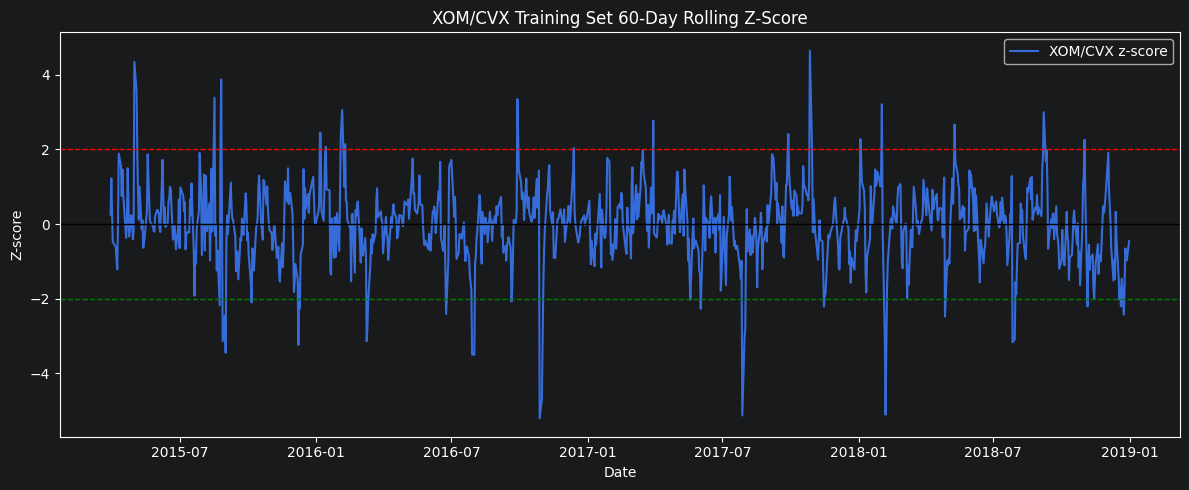

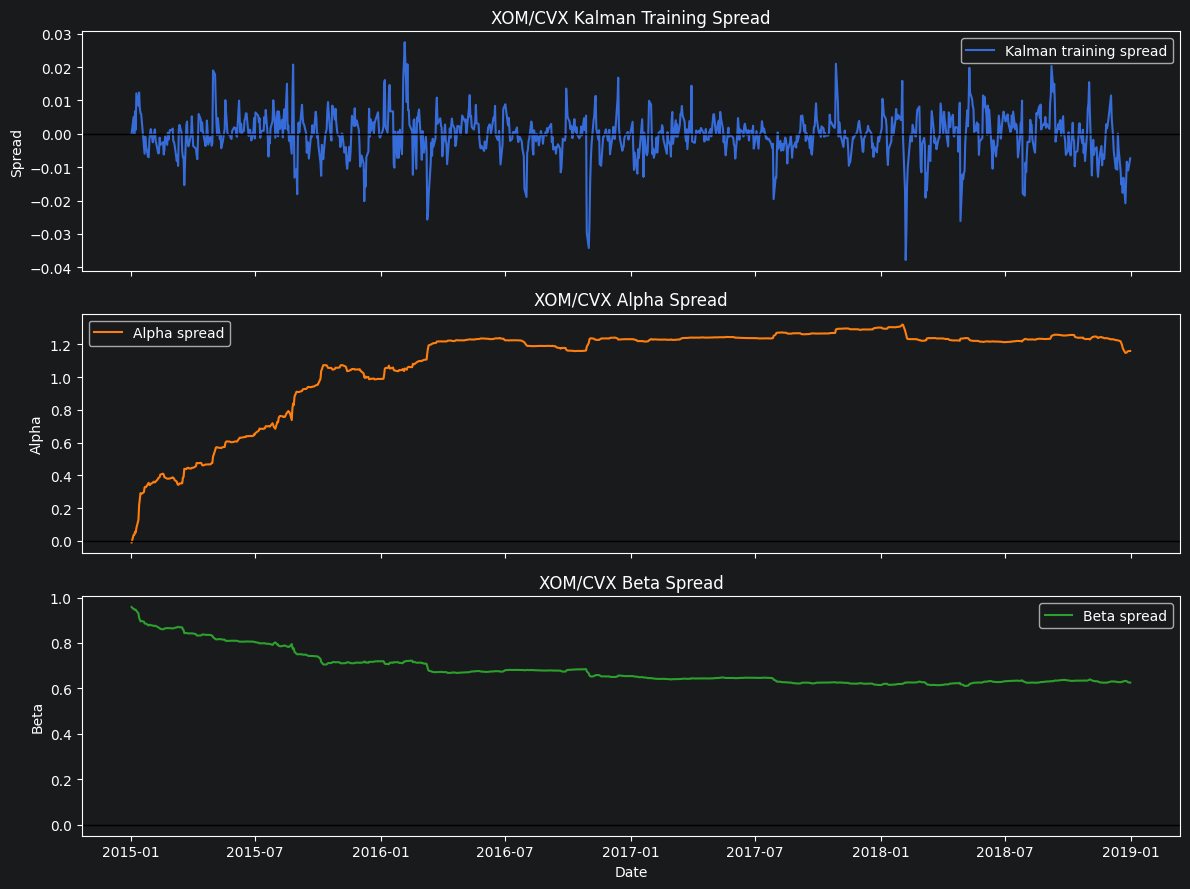

In [71]:
Z_LOOKBACK = 60

training_set = train_pair_data[("XOM", "CVX")].copy().reset_index(drop=True)

kalman_training = kalman_filter_beta(
    y=training_set["log_XOM"],
    x=training_set["log_CVX"]
)

training_set = pd.concat([training_set, kalman_training], axis=1)
training_set["spread_mean"] = training_set["spread"].rolling(Z_LOOKBACK).mean()
training_set["spread_std"] = training_set["spread"].rolling(Z_LOOKBACK).std()
training_set["z"] = (training_set["spread"] - training_set["spread_mean"]) / training_set["spread_std"]

plt.figure(figsize=(12, 5))
plt.plot(training_set["Date"], training_set["z"], label="XOM/CVX z-score")
plt.axhline(0, color="black", linewidth=1)
plt.axhline(2, color="red", linestyle="--", linewidth=1)
plt.axhline(-2, color="green", linestyle="--", linewidth=1)
plt.title("XOM/CVX Training Set 60-Day Rolling Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(training_set["Date"], training_set["spread"], label="Kalman training spread")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("XOM/CVX Kalman Training Spread")
axes[0].set_ylabel("Spread")
axes[0].legend()

axes[1].plot(training_set["Date"], training_set["alpha_kalman"], label="Alpha spread", color="tab:orange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("XOM/CVX Alpha Spread")
axes[1].set_ylabel("Alpha")
axes[1].legend()

axes[2].plot(training_set["Date"], training_set["beta_kalman"], label="Beta spread", color="tab:green")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("XOM/CVX Beta Spread")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Beta")
axes[2].legend()

plt.tight_layout()
plt.show()

,period,total_pnl,annual_pnl,daily_vol,sharpe,max_drawdown,entries,exposure
0,train,3564.1846,893.7060,15.6024,3.6083,-103.7610,59,0.2008
1,valid,3429.9370,1143.3123,27.8531,2.5858,-247.4859,45,0.2127
2,test,4438.2617,1000.3953,16.0948,3.9155,-123.9516,69,0.1993


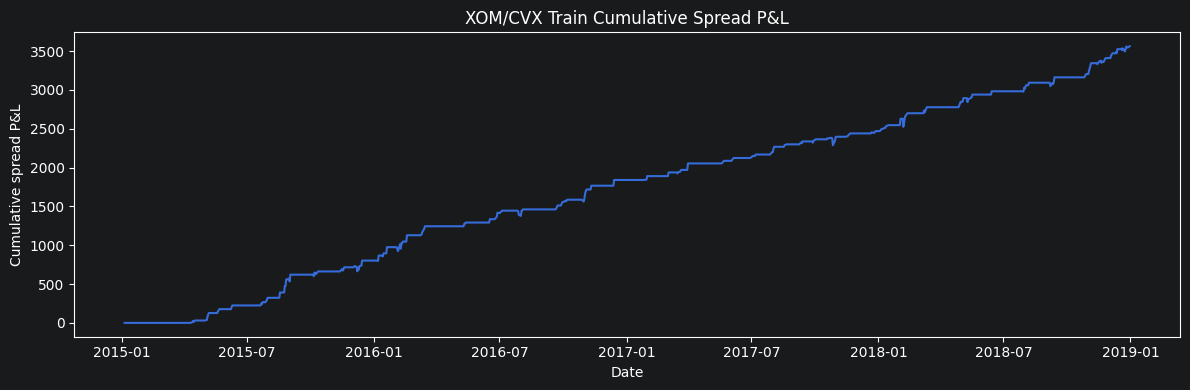

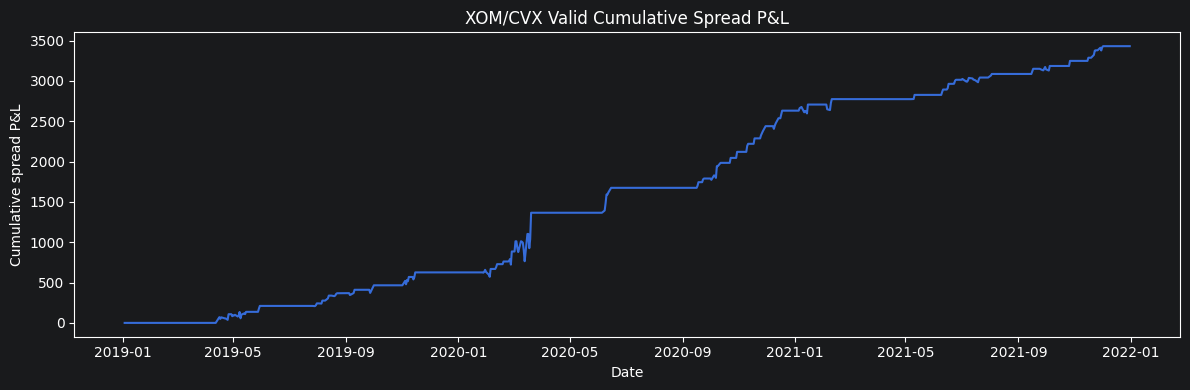

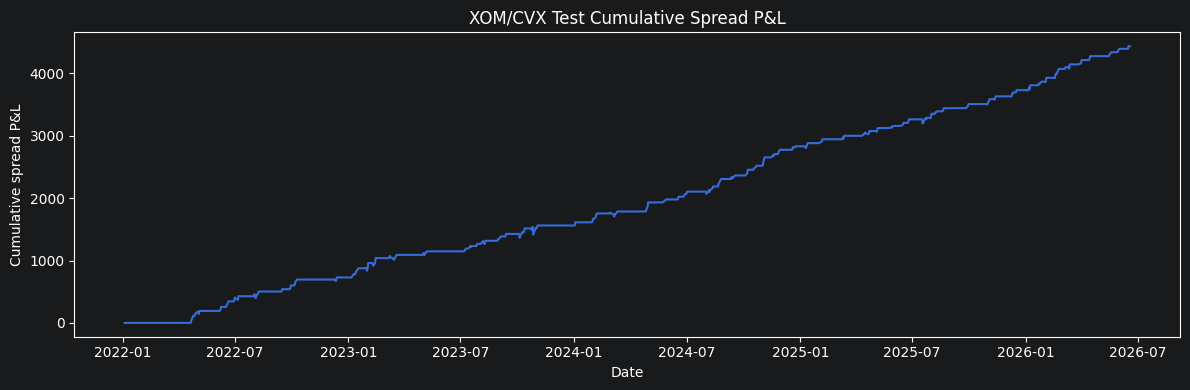

In [72]:
# Basic backtest XOM/CVX z-score strategy with larger position limits

def prepare_xom_cvx_set(source_df):
    result = source_df.copy().reset_index(drop=True)
    kalman_result = kalman_filter_beta(
        y=result["log_XOM"],
        x=result["log_CVX"]
    )
    result = pd.concat([result, kalman_result], axis=1)
    result["spread_mean"] = result["spread"].rolling(Z_LOOKBACK).mean()
    result["spread_std"] = result["spread"].rolling(Z_LOOKBACK).std()
    result["z"] = (result["spread"] - result["spread_mean"]) / result["spread_std"]
    return result


def generate_positions(df, entry_z=1.5, exit_z=0.5, position_limit=100):
    result = df.copy()
    positions = []
    current_pos = 0

    for z in result["z"]:
        if pd.isna(z):
            positions.append(current_pos)
            continue

        if current_pos == 0:
            if z > entry_z:
                current_pos = -position_limit
            elif z < -entry_z:
                current_pos = position_limit
        elif current_pos > 0 and z >= -exit_z:
            current_pos = 0
        elif current_pos < 0 and z <= exit_z:
            current_pos = 0

        positions.append(current_pos)

    result["position"] = positions
    return result


def run_spread_backtest(df, position_limit):
    result = generate_positions(df, position_limit=position_limit)
    result["spread_change"] = result["spread"].diff()
    result["pnl"] = result["position"].shift(1).fillna(0) * result["spread_change"]
    result["cum_pnl"] = result["pnl"].cumsum()
    result["drawdown"] = result["cum_pnl"] - result["cum_pnl"].cummax()

    daily_vol = result["pnl"].std()
    sharpe = np.nan if daily_vol == 0 or pd.isna(daily_vol) else np.sqrt(252) * result["pnl"].mean() / daily_vol
    entries = ((result["position"] != 0) & (result["position"].shift(1).fillna(0) == 0)).sum()

    return {
        "position_limit": position_limit,
        "total_pnl": result["pnl"].sum(),
        "annual_pnl": result["pnl"].mean() * 252,
        "daily_vol": daily_vol,
        "sharpe": sharpe,
        "max_drawdown": result["drawdown"].min(),
        "entries": int(entries),
        "exposure": result["position"].ne(0).mean(),
    }


xom_cvx_sets = {
    "train": prepare_xom_cvx_set(train_pair_data[("XOM", "CVX")]),
    "valid": prepare_xom_cvx_set(valid_pair_data[("XOM", "CVX")]),
    "test": prepare_xom_cvx_set(test_pair_data[("XOM", "CVX")]),
}

position_limit_results = []

for period_name, period_df in xom_cvx_sets.items():
    for position_limit in [5000]:
        stats = run_spread_backtest(period_df, position_limit)
        stats["period"] = period_name
        position_limit_results.append(stats)

position_limit_results = pd.DataFrame(position_limit_results)
position_limit_results = position_limit_results[
    ["period", "total_pnl", "annual_pnl", "daily_vol", "sharpe", "max_drawdown", "entries", "exposure"]
]

display(position_limit_results.round(4))

for period_name, period_df in xom_cvx_sets.items():
    plt.figure(figsize=(12, 4))
    for position_limit in [5000]:
        backtest_df = generate_positions(period_df, position_limit=position_limit)
        backtest_df["spread_change"] = backtest_df["spread"].diff()
        backtest_df["pnl"] = backtest_df["position"].shift(1).fillna(0) * backtest_df["spread_change"]
        backtest_df["cum_pnl"] = backtest_df["pnl"].cumsum()
        plt.plot(backtest_df["Date"], backtest_df["cum_pnl"], label=f"limit={position_limit}")

    plt.title(f"XOM/CVX {period_name.title()} Cumulative Spread P&L")
    plt.xlabel("Date")
    plt.ylabel("Cumulative spread P&L")
    plt.tight_layout()
    plt.show()


## Backtest conclusion

 The XOM/CVX pair passed both the cointegration and mean-reversion gates, and the initial spread-based backtest produced positive results across the training, validation, and test periods.

These results are only preliminary. The current backtest is simplified and should be extended with transaction costs, slippage, capital normalization, borrow/financing assumptions, and hyperparameter tuning before drawing any production-level conclusion.
